# 30 天再入院风险模型训练（XGBoost）

基于 MIMIC-IV 数据训练 XGBoost 二分类模型，预测患者出院后 30 天内再入院风险。

**本 notebook 完全自包含**：特征工程 + 训练 + 可视化都在这里，不依赖 `src`（训练/推理分离）。

流程：特征工程 → 数据概览 → 类别分布 → 5 折交叉验证 → 全量训练 → 混淆矩阵 / ROC / 校准曲线 → 特征重要性 → 保存模型

> 注意：
> 1. 运行前请确认 `backend/data/mimic/` 下有 ADMISSIONS / PATIENTS / DIAGNOSES_ICD / ICUSTAYS 四张 CSV。
> 2. 请从 `backend/` 启动 Jupyter（或确认 cwd 是 backend/），否则 `models/` 相对路径会错位。
> 3. 下面的 `FEATURE_COLS` 与推理侧 `src/ml/expert_risk_tool.py` 的 `FEATURE_COLS` **需人工保持一致**（训练/推理分离的代价，两边各自维护）。

推荐**只执行一次**，安装完重启内核

In [15]:
%pip install xgboost numpy pandas matplotlib scikit-learn pyarrow  mlflow -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
      --------------------------------------- 0.3/11.6 MB ? eta -:--:--
     --- ------------------------------------ 1.0/11.6 MB 3.9 MB/s eta 0:00:03
     ------- -------------------------------- 2.1/11.6 MB 5.1 MB/s eta 0:00:02
     -------------- ------------------------- 4.2/11.6 MB 6.5 MB/s eta 0:00:02
     -------------------- ------------------- 6.0/11.6 MB 7.1 MB/s eta 0:00:01
     ---------------------- ----------------- 6.6/11.6 MB 7.3 MB/s eta 0:00:01
     ------------------------------------ --- 10.5/11.6 MB 8.5 MB/s eta 0:00:01
     ---------------------------------------- 11.6/11.6 MB 8.5 MB/s  0:00:01
     ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
     ------------------------- -------------- 2.4/3.7 MB 11.2 MB/s eta 0:00:01
     ---------------------------------------  3.7/3.7 MB 8.7 MB/s eta 0:00:01
     ----------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    brier_score_loss, roc_curve, auc,
)
from sklearn.calibration import calibration_curve

# ===== 特征列契约（训练侧自己定义，与推理侧 src/ml/expert_risk_tool.py 的 FEATURE_COLS 保持一致）=====
FEATURE_COLS = [
    "age", "gender_m", "admission_type_emergency",
    "los_days", "diagnosis_count",
    "has_diabetes", "has_heart_failure", "has_hypertension",
    "has_renal_disease", "has_pneumonia", "has_sepsis", "has_copd",
    "num_icu_stays", "total_icu_los", "max_icu_los",
]
TARGET_COL = "readmitted_30d"
MIMIC_DIR = Path("./mimic")
MODEL_PATH = Path("readmission_model.json")
MLFLOW_EXPERIMENT = "medicineAgent-readmission"

print("依赖加载完成，特征列：", FEATURE_COLS)

In [2]:
# ===== 特征工程：加载四张 MIMIC CSV =====
def load_admissions() -> pd.DataFrame:
    df = pd.read_csv(MIMIC_DIR / "ADMISSIONS.csv")
    df.columns = df.columns.str.lower()
    for col in ["admittime", "dischtime", "deathtime", "edregtime", "edouttime"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def load_patients() -> pd.DataFrame:
    df = pd.read_csv(MIMIC_DIR / "PATIENTS.csv")
    df.columns = df.columns.str.lower()
    for col in ["dob", "dod"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def load_diagnoses() -> pd.DataFrame:
    df = pd.read_csv(MIMIC_DIR / "DIAGNOSES_ICD.csv")
    df.columns = df.columns.str.lower()
    return df

def load_icustays() -> pd.DataFrame:
    df = pd.read_csv(MIMIC_DIR / "ICUSTAYS.csv")
    df.columns = df.columns.str.lower()
    for col in ["intime", "outtime"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

In [3]:
# ===== 年龄 & 再入院标签 =====
def compute_age(patients: pd.DataFrame, admissions: pd.DataFrame) -> pd.DataFrame:
    merged = admissions.merge(patients[["subject_id", "dob", "gender"]], on="subject_id", how="left")
    merged["age"] = merged["admittime"].dt.year - merged["dob"].dt.year  # 年份相减粗略估算
    merged["age"] = merged["age"].clip(upper=90)  # MIMIC 将 >89 岁掩码为约 300，裁剪到 90
    return merged

def build_readmission_label(admissions: pd.DataFrame) -> pd.DataFrame:
    adm = admissions.sort_values(["subject_id", "admittime"]).copy()
    adm["next_admittime"] = adm.groupby("subject_id")["admittime"].shift(-1)
    adm["days_to_readmission"] = (adm["next_admittime"] - adm["dischtime"]).dt.days
    adm["readmitted_30d"] = (
        (adm["days_to_readmission"] >= 0) & (adm["days_to_readmission"] <= 30)
    ).astype(int)
    return adm

In [4]:
# ===== 诊断 & ICU 特征 =====
def build_diagnosis_features(diagnoses: pd.DataFrame, admissions: pd.DataFrame) -> pd.DataFrame:
    diag_count = diagnoses.groupby("hadm_id").size().reset_index(name="diagnosis_count")
    conditions = {
        "has_diabetes": ["250"],
        "has_heart_failure": ["428"],
        "has_hypertension": ["401", "402", "403", "404", "405"],
        "has_renal_disease": ["585", "586", "403"],
        "has_pneumonia": ["486", "485", "481", "482", "483", "484"],
        "has_sepsis": ["038", "995"],
        "has_copd": ["491", "492", "496"],
    }
    flags = pd.DataFrame({"hadm_id": admissions["hadm_id"].unique()})
    for flag_name, prefixes in conditions.items():
        matching = diagnoses[
            diagnoses["icd9_code"].astype(str).str.startswith(tuple(prefixes))
        ]["hadm_id"].unique()
        flags[flag_name] = flags["hadm_id"].isin(matching).astype(int)
    flags = flags.merge(diag_count, on="hadm_id", how="left")
    flags["diagnosis_count"] = flags["diagnosis_count"].fillna(0)
    return flags

def build_icu_features(icustays: pd.DataFrame) -> pd.DataFrame:
    icu = icustays.copy()
    icu["icu_los"] = icu["los"]
    return icu.groupby("hadm_id").agg(
        num_icu_stays=("icustay_id", "count"),
        total_icu_los=("icu_los", "sum"),
        max_icu_los=("icu_los", "max"),
    ).reset_index()

In [5]:
# ===== 主入口：串联特征工程 =====
def build_feature_matrix() -> pd.DataFrame:
    print("loading_mimic_tables")
    admissions = load_admissions()
    patients = load_patients()
    diagnoses = load_diagnoses()
    icustays = load_icustays()

    print("computing_readmission_labels")
    admissions = build_readmission_label(admissions)
    print("computing_patient_age")
    admissions = compute_age(patients, admissions)
    print("building_diagnosis_features")
    diag_features = build_diagnosis_features(diagnoses, admissions)
    print("building_icu_features")
    icu_features = build_icu_features(icustays)

    print("joining_features")
    df = admissions.merge(diag_features, on="hadm_id", how="left")
    df = df.merge(icu_features, on="hadm_id", how="left")

    df["admission_type_emergency"] = (df["admission_type"] == "EMERGENCY").astype(int)
    df["gender_m"] = (df["gender"] == "M").astype(int)
    df["los_days"] = (df["dischtime"] - df["admittime"]).dt.days
    df["num_icu_stays"] = df["num_icu_stays"].fillna(0)
    df["total_icu_los"] = df["total_icu_los"].fillna(0)
    df["max_icu_los"] = df["max_icu_los"].fillna(0)

    df = df[df["hospital_expire_flag"] == 0].copy()  # 剔除院内死亡
    final = df[FEATURE_COLS + [TARGET_COL, "hadm_id", "subject_id"]].copy()
    final = final.dropna(subset=FEATURE_COLS)

    print(f"feature_matrix_built: admissions={len(final)}, readmissions={int(final[TARGET_COL].sum())}")
    print(f"readmission_rate: {final[TARGET_COL].mean():.4f}")
    return final

In [ ]:
# 加载特征矩阵
df = build_feature_matrix()
X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"\n样本数: {len(df)}，再入院正样本: {int(y.sum())} ({y.mean():.2%})")
df[FEATURE_COLS].describe().T

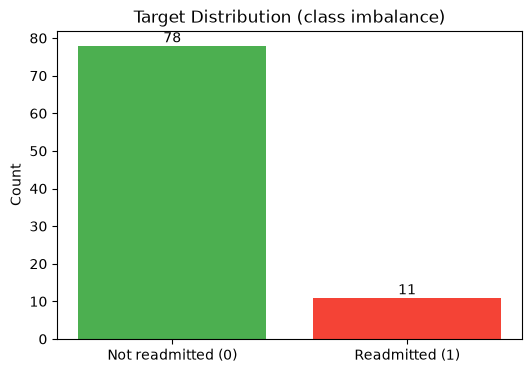

In [7]:
# 目标变量分布（观察类别不平衡）
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Not readmitted (0)", "Readmitted (1)"], counts.values, color=["#4CAF50", "#F44336"])
ax.set_title("Target Distribution (class imbalance)")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

In [8]:
# 5 折分层交叉验证
neg, pos = int((y == 0).sum()), int((y == 1).sum())
scale_pos_weight = neg / pos if pos > 0 else 1
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

params = {
    "n_estimators": 100,
    "max_depth": 4,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "auc",
    "random_state": 42,
}

model = XGBClassifier(**params)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
print(f"CV AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

scale_pos_weight: 7.09
CV AUC (5-fold): 0.5867 ± 0.2094


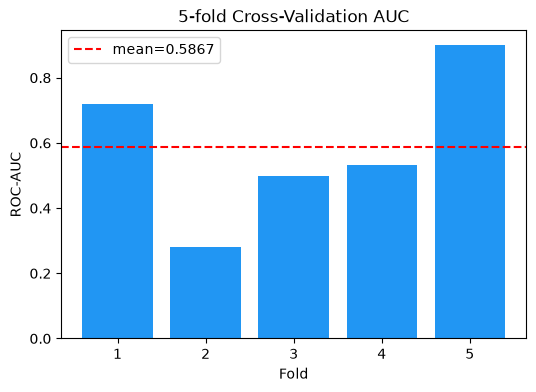

In [9]:
# 各折 AUC 分布
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 6), cv_scores, color="#2196F3")
ax.axhline(cv_scores.mean(), color="red", linestyle="--", label=f"mean={cv_scores.mean():.4f}")
ax.set_xlabel("Fold")
ax.set_ylabel("ROC-AUC")
ax.set_title("5-fold Cross-Validation AUC")
ax.legend()
plt.show()

In [10]:
# 全量训练 + 训练集评估
model.fit(X, y)
y_pred_proba = model.predict_proba(X)[:, 1]
y_pred = model.predict(X)

train_auc = roc_auc_score(y, y_pred_proba)
brier = brier_score_loss(y, y_pred_proba)
print(f"Train AUC: {train_auc:.4f}")
print(f"Brier Score: {brier:.4f}")
print("\n分类报告:")
print(classification_report(y, y_pred, target_names=["Not readmitted", "Readmitted"]))

Train AUC: 1.0000
Brier Score: 0.0064

分类报告:
                precision    recall  f1-score   support

Not readmitted       1.00      1.00      1.00        78
    Readmitted       1.00      1.00      1.00        11

      accuracy                           1.00        89
     macro avg       1.00      1.00      1.00        89
  weighted avg       1.00      1.00      1.00        89



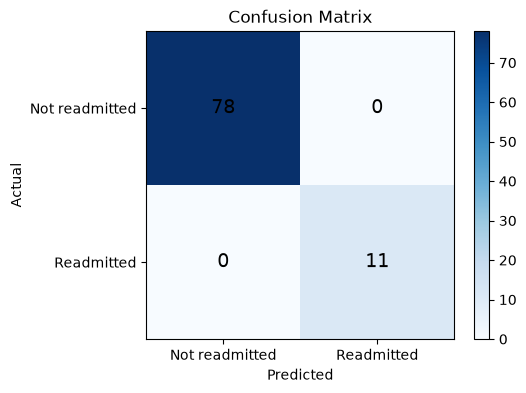

In [11]:
# 混淆矩阵热力图
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Not readmitted", "Readmitted"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Not readmitted", "Readmitted"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
plt.colorbar(im)
plt.show()

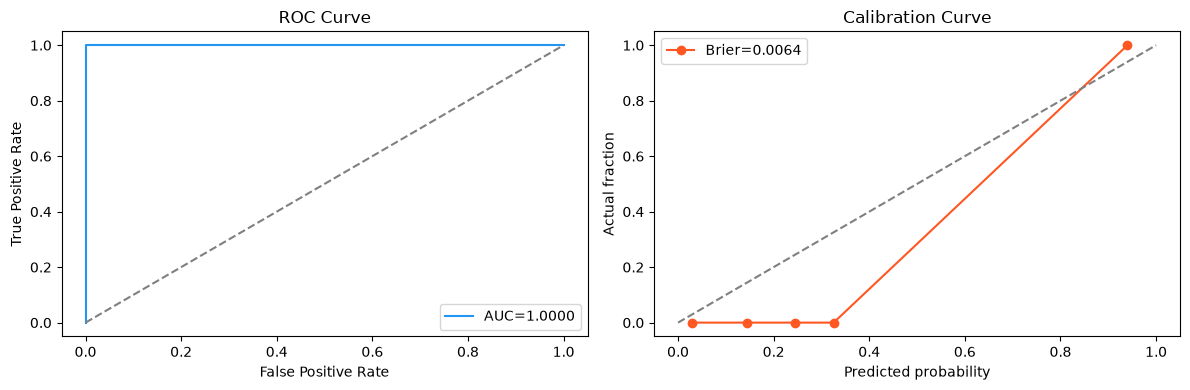

In [12]:
# ROC 曲线 + 校准曲线
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)
prob_true, prob_pred = calibration_curve(y, y_pred_proba, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color="#2196F3", label=f"AUC={roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(prob_pred, prob_true, marker="o", color="#FF5722", label=f"Brier={brier:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Actual fraction")
axes[1].set_title("Calibration Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

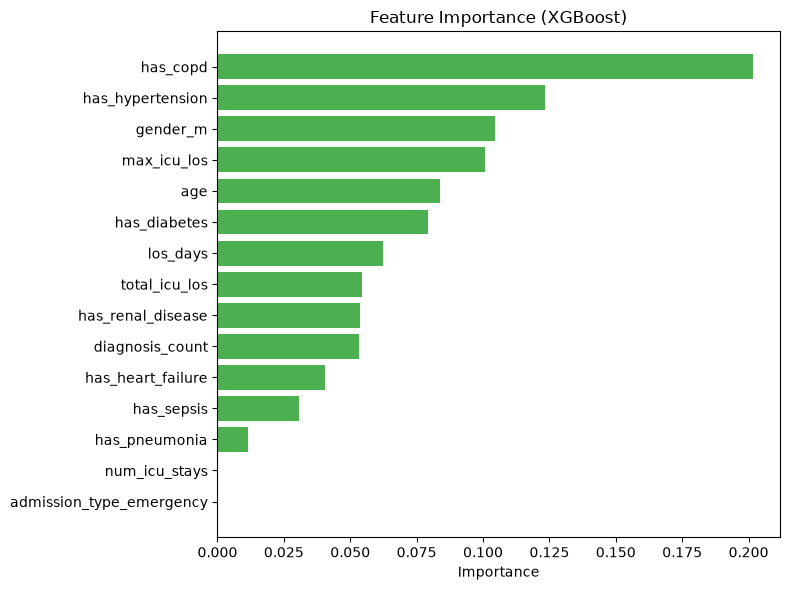

In [13]:
# 特征重要性（水平 bar 图）
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": model.feature_importances_,
}).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance["feature"], importance["importance"], color="#4CAF50")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

In [ ]:
# 保存模型 + MLflow 追踪（超参 / 指标 / 模型工件可追溯）
model.save_model(str(MODEL_PATH))
print(f"模型已保存到 {MODEL_PATH}")

mlflow.set_experiment(MLFLOW_EXPERIMENT)
with mlflow.start_run(run_name="xgboost-readmission-v1"):
    mlflow.log_params(params)
    mlflow.log_param("n_samples", len(df))
    mlflow.log_param("n_features", len(FEATURE_COLS))
    mlflow.log_param("positive_rate", round(float(y.mean()), 4))
    mlflow.log_metric("cv_auc_mean", round(float(cv_scores.mean()), 4))
    mlflow.log_metric("cv_auc_std", round(float(cv_scores.std()), 4))
    mlflow.log_metric("train_auc", round(float(train_auc), 4))
    mlflow.log_metric("brier_score", round(float(brier), 4))
    mlflow.xgboost.log_model(model, "xgboost_readmission_model")
    run_id = mlflow.active_run().info.run_id
    print(f"MLflow run_id: {run_id}")
    print("推理侧 src/ml/expert_risk_tool.py 经 config 的 RISK_MODEL_PATH 读取该模型。")